# Phase 6: Visualization

Presentation-ready charts summarizing the Phase 5 results, for a
non-technical audience. This is deliberately separate from the technical
diagnostic plots already in the Phase 5 notebooks (elbow/silhouette,
SHAP beeswarm, example trend fits) — those are for verifying the models
worked; these are for communicating what they found.

Each chart is exported to `outputs/` as a PNG in addition to rendering
inline, per the project's folder structure.

**Color choices** follow a consistent scheme throughout, not picked
per-chart:
- **Categorical** (the 3 segments): blue / aqua / yellow, in that fixed
  order every time a segment appears in a chart — so "Segment 0" is
  always the same color across figures.
- **Status** (open vs. closed): green (open) / red (closed) — a real
  good/critical status pairing, not an arbitrary two-category choice.
- **Diverging** (SHAP risk direction): blue (reduces risk) vs. red
  (increases risk), with gray as neutral — matches the "opposite poles"
  framing of the earlier analysis.

## Setup: shared styling and data

Colors come from a validated, colorblind-safe reference palette (see
`references/palette.md` in the project's dataviz skill) rather than
matplotlib's defaults — its ordering was specifically chosen to maximize
color separation for colorblind viewers.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs('../outputs', exist_ok=True)

# validated reference palette (dataviz skill) — fixed slot order, not re-ordered per chart
CATEGORICAL = ['#2a78d6', '#1baf7a', '#eda100']  # blue, aqua, yellow — segments 0, 1, 2 always in this order
STATUS_GOOD = '#0ca30c'      # open
STATUS_CRITICAL = '#d03b3b'  # closed
DIVERGING_LESS_RISK = '#2a78d6'  # blue
DIVERGING_MORE_RISK = '#e34948'  # red
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRIDLINE = '#e1e0d9'
BASELINE = '#c3c2b7'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'axes.edgecolor': BASELINE,
    'axes.labelcolor': INK_SECONDARY,
    'text.color': INK_PRIMARY,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'grid.color': GRIDLINE,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

segment_names = {
    0: 'Struggling / Mixed-Experience',
    1: 'Steady Mainstream Favorites',
    2: 'High-Traffic Bars & Nightlife',
}

business_features = pd.read_csv('../data/business_features.csv')
business_segments = pd.read_csv('../data/business_segments.csv')
business_growth = pd.read_csv('../data/business_growth_trend.csv')

business_features.shape, business_segments.shape, business_growth.shape

((14560, 23), (14560, 4), (14560, 3))

## Segmentation: sizes and closure rate

Two panels side by side: how big each segment is, and — the key
cross-validated finding from Phase 5a/5b — closure rate by segment. Same
segment colors in both panels, same order, so a reader can track one
segment across the pair.

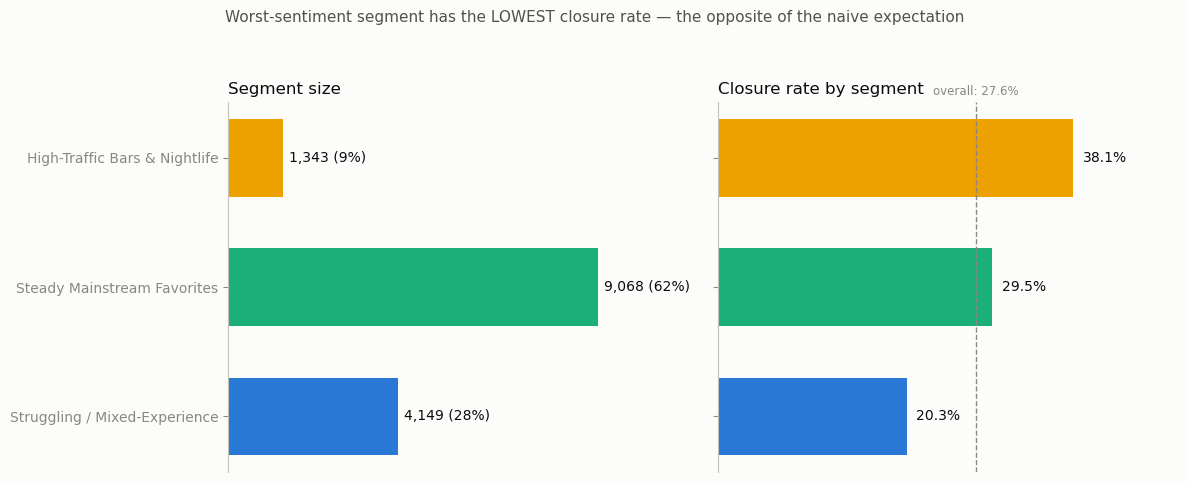

In [2]:
segment_risk = business_segments.merge(business_features[['business_id', 'risk_proxy_closed']], on='business_id')
segment_summary = segment_risk.groupby('segment').agg(
    n=('business_id', 'count'),
    closure_rate=('risk_proxy_closed', 'mean'),
).sort_index()
segment_summary['name'] = segment_summary.index.map(segment_names)
overall_closure_rate = business_features['risk_proxy_closed'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# panel 1: segment sizes
bars0 = axes[0].barh(segment_summary['name'], segment_summary['n'], color=CATEGORICAL, height=0.6)
for bar, n in zip(bars0, segment_summary['n']):
    axes[0].text(bar.get_width() + 150, bar.get_y() + bar.get_height() / 2,
                 f'{n:,} ({n / segment_summary["n"].sum():.0%})', va='center', fontsize=10, color=INK_PRIMARY)
axes[0].set_title('Segment size', loc='left', fontsize=12, color=INK_PRIMARY)
axes[0].set_xlim(0, segment_summary['n'].max() * 1.25)
axes[0].tick_params(axis='y', labelsize=10)
axes[0].xaxis.set_visible(False)
for spine in ['top', 'right', 'bottom']:
    axes[0].spines[spine].set_visible(False)

# panel 2: closure rate by segment, with overall rate as reference line
bars1 = axes[1].barh(segment_summary['name'], segment_summary['closure_rate'], color=CATEGORICAL, height=0.6)
for bar, rate in zip(bars1, segment_summary['closure_rate']):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                 f'{rate:.1%}', va='center', fontsize=10, color=INK_PRIMARY)
axes[1].axvline(overall_closure_rate, color=INK_MUTED, linewidth=1, linestyle='--')
# x in data coords, y in axes-fraction coords — keeps the label anchored just above the line regardless of the categorical y-axis
axes[1].text(overall_closure_rate, 1.02, f'overall: {overall_closure_rate:.1%}',
             transform=axes[1].get_xaxis_transform(), fontsize=8.5, color=INK_MUTED, ha='center')
axes[1].set_title('Closure rate by segment', loc='left', fontsize=12, color=INK_PRIMARY)
axes[1].set_xlim(0, segment_summary['closure_rate'].max() * 1.3)
axes[1].tick_params(axis='y', labelsize=10, labelleft=False)
axes[1].xaxis.set_visible(False)
for spine in ['top', 'right', 'bottom']:
    axes[1].spines[spine].set_visible(False)

fig.suptitle('Worst-sentiment segment has the LOWEST closure rate — the opposite of the naive expectation', fontsize=11, color=INK_SECONDARY, y=1.06)
plt.tight_layout()
plt.savefig('../outputs/segment_size_and_closure_rate.png', dpi=150, bbox_inches='tight')
plt.show()

## Risk model: rebuild the pipeline

`04b_risk_classification.ipynb` doesn't persist its trained model or SHAP
values to disk — only the raw feature/target data exists as a shared file.
Rather than adding new save/load plumbing to that notebook, this cell
**re-runs the exact same pipeline** (identical feature selection, same
`random_state=42` split, same model). This is fully reproducible, not a
re-derivation that risks drifting from the original — same code, same
inputs, same outputs.

In [3]:
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import shap

bf = business_features.copy()
numeric_features = [
    'review_count_actual', 'sentiment_compound_mean', 'sentiment_compound_std',
    'pct_negative_reviews', 'pct_positive_reviews', 'text_word_count_mean',
    'text_exclamation_count_mean', 'text_question_count_mean',
    'text_caps_word_ratio_mean', 'category_count',
]
category_lists = bf['categories'].str.split(',').apply(lambda cats: [c.strip() for c in cats])
top_categories = [cat for cat, _ in Counter(c for cats in category_lists for c in cats).most_common(15)]
category_features = []
for cat in top_categories:
    col = f'cat_{cat.lower().replace(" ", "_").replace("&", "and")}'
    bf[col] = category_lists.apply(lambda cats: int(cat in cats))
    category_features.append(col)

feature_cols = numeric_features + category_features
X = bf[feature_cols]
y = bf['risk_proxy_closed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

risk_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
risk_model.fit(X_train_scaled, y_train)
y_proba = risk_model.predict_proba(X_test_scaled)[:, 1]

masker = shap.maskers.Independent(X_train_scaled, max_samples=X_train_scaled.shape[0])
explainer = shap.Explainer(risk_model, masker=masker, feature_names=feature_cols)
shap_values = explainer(X_test_scaled)

roc_auc_score(y_test, y_proba)  # should match 04b's reported 0.7428

0.7427981852859589

## Risk drivers: top 10 SHAP features

A cleaner, presentation version of Phase 5b's SHAP bar chart — sorted by
impact magnitude, colored by direction (diverging blue/red) rather than
matplotlib's default single hue, with plain-language feature names.

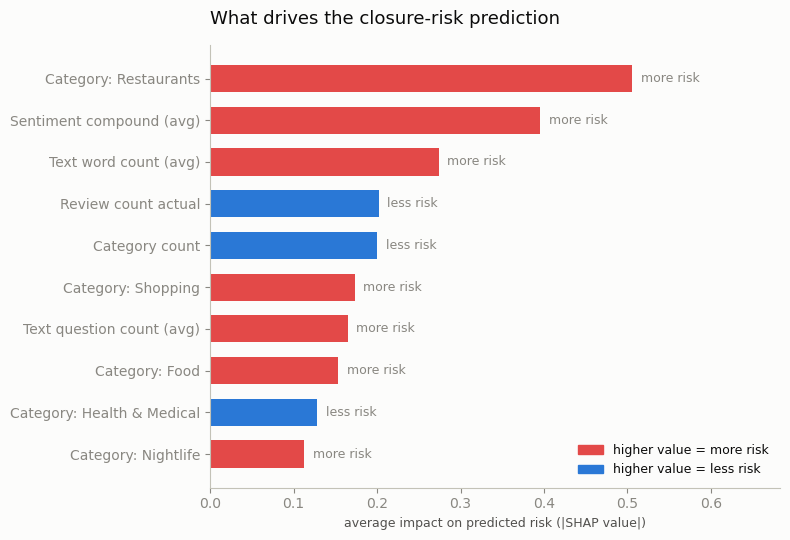

In [4]:
def pretty_label(col):
    if col.startswith('cat_'):
        return 'Category: ' + col[4:].replace('_', ' ').replace('and', '&').title()
    return col.replace('_', ' ').replace('mean', '(avg)').capitalize()

mean_abs_shap = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feature_cols)
coefs = pd.Series(risk_model.coef_[0], index=feature_cols)
top10 = mean_abs_shap.sort_values(ascending=False).head(10).index[::-1]  # reversed so largest is at top of horizontal bar chart

colors = [DIVERGING_MORE_RISK if coefs[f] > 0 else DIVERGING_LESS_RISK for f in top10]
labels = [pretty_label(f) for f in top10]

fig, ax = plt.subplots(figsize=(8, 5.5))
bars = ax.barh(labels, mean_abs_shap[top10], color=colors, height=0.65)
for bar, f in zip(bars, top10):
    direction = 'more risk' if coefs[f] > 0 else 'less risk'
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2, direction,
            va='center', fontsize=9, color=INK_MUTED)

ax.set_title('What drives the closure-risk prediction', loc='left', fontsize=13, color=INK_PRIMARY, pad=15)
ax.set_xlabel('average impact on predicted risk (|SHAP value|)', fontsize=9)
ax.set_xlim(0, mean_abs_shap[top10].max() * 1.35)
ax.tick_params(axis='y', labelsize=10)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=DIVERGING_MORE_RISK, label='higher value = more risk'),
    plt.Rectangle((0, 0), 1, 1, color=DIVERGING_LESS_RISK, label='higher value = less risk'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('../outputs/risk_shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC curve

Not built in Phase 5b (only the AUC number was reported there) — this
gives the full curve, showing how the model trades off catching more
closures against more false alarms across every possible threshold, not
just the single default one.

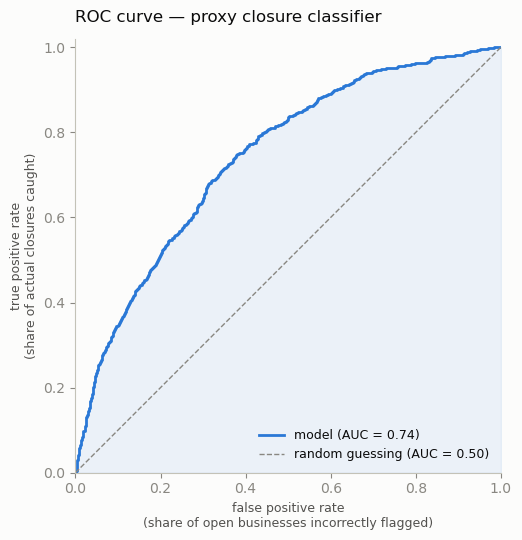

In [5]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr, tpr, color=CATEGORICAL[0], linewidth=2, label=f'model (AUC = {auc:.2f})')
ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle='--', label='random guessing (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color=CATEGORICAL[0])

ax.set_xlabel('false positive rate\n(share of open businesses incorrectly flagged)', fontsize=9)
ax.set_ylabel('true positive rate\n(share of actual closures caught)', fontsize=9)
ax.set_title('ROC curve — proxy closure classifier', loc='left', fontsize=12, color=INK_PRIMARY, pad=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.legend(loc='lower right', fontsize=9, frameon=False)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('../outputs/risk_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## The headline finding: sentiment by closure status

The single most important, most counter-intuitive result across all of
Phase 5 — confirmed three independent ways (Phase 4 group means, Phase 5a
segment cross-tab, Phase 5b SHAP) — visualized directly: closed businesses
skew toward *higher* sentiment than open ones. Status colors (green =
open, red = closed) are the right encoding here since this genuinely is a
two-state status comparison, not an arbitrary categorical split.

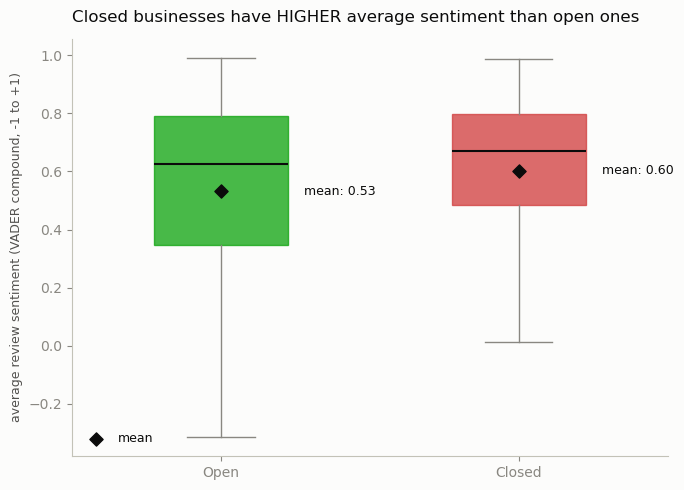

In [6]:
open_sentiment = business_features.loc[business_features['risk_proxy_closed'] == 0, 'sentiment_compound_mean']
closed_sentiment = business_features.loc[business_features['risk_proxy_closed'] == 1, 'sentiment_compound_mean']

fig, ax = plt.subplots(figsize=(7, 5))
bp = ax.boxplot(
    [open_sentiment, closed_sentiment],
    tick_labels=['Open', 'Closed'],
    patch_artist=True, widths=0.45, showfliers=False, medianprops={'color': INK_PRIMARY, 'linewidth': 1.5},
)
for patch, color in zip(bp['boxes'], [STATUS_GOOD, STATUS_CRITICAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
    patch.set_edgecolor(color)
for element in ['whiskers', 'caps']:
    for line in bp[element]:
        line.set_color(INK_MUTED)

for i, (data, color) in enumerate(zip([open_sentiment, closed_sentiment], [STATUS_GOOD, STATUS_CRITICAL]), start=1):
    ax.scatter(i, data.mean(), marker='D', s=45, color=INK_PRIMARY, zorder=3, label='mean' if i == 1 else None)
    ax.text(i + 0.28, data.mean(), f'mean: {data.mean():.2f}', va='center', fontsize=9, color=INK_PRIMARY)

ax.set_ylabel('average review sentiment (VADER compound, -1 to +1)', fontsize=9)
ax.set_title('Closed businesses have HIGHER average sentiment than open ones', loc='left', fontsize=12, color=INK_PRIMARY, pad=12)
ax.legend(loc='lower left', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('../outputs/sentiment_by_closure_status.png', dpi=150, bbox_inches='tight')
plt.show()

## Growth trend distribution

How review-volume momentum is distributed across the businesses that
cleared the 6-active-month threshold. This is a single-series magnitude
distribution, so it uses the sequential blue ramp rather than the
categorical palette — there's no "identity" being encoded here, just how
many businesses fall in each range.

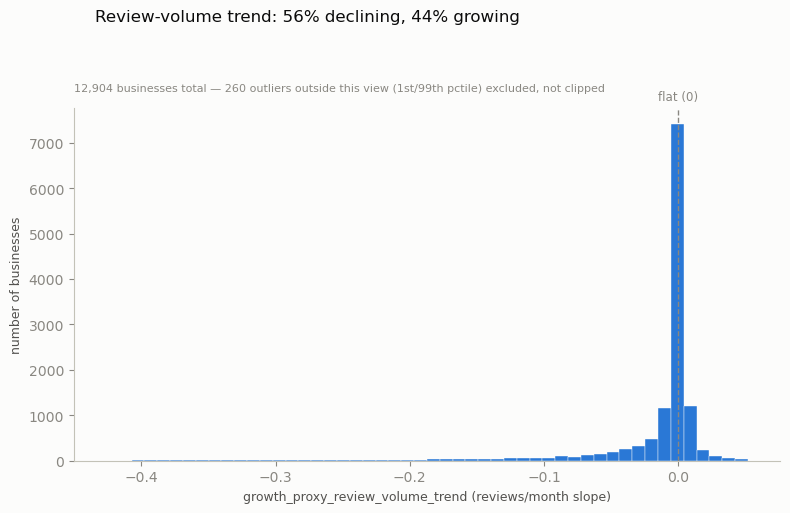

In [7]:
valid_trend = business_growth['growth_proxy_review_volume_trend'].dropna()

# filter (not clip) to the 1st-99th percentile for display — clipping would pile every outlier
# into one bin exactly at the boundary, creating a fake spike that isn't real data
p1, p99 = valid_trend.quantile([0.01, 0.99])
display_trend = valid_trend[(valid_trend >= p1) & (valid_trend <= p99)]
n_excluded = len(valid_trend) - len(display_trend)

declining_pct = (valid_trend < 0).mean()
growing_pct = (valid_trend > 0).mean()

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(display_trend, bins=50, color=CATEGORICAL[0], edgecolor=SURFACE, linewidth=0.3)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle='--')
ax.text(0, 1.02, 'flat (0)', transform=ax.get_xaxis_transform(), fontsize=8.5, color=INK_MUTED, ha='center')

fig.suptitle(f'Review-volume trend: {declining_pct:.0%} declining, {growing_pct:.0%} growing',
             fontsize=12, color=INK_PRIMARY, x=0.125, ha='left', y=1.06)
ax.set_title(f'{len(valid_trend):,} businesses total — {n_excluded} outliers outside this view (1st/99th pctile) excluded, not clipped',
             loc='left', fontsize=8, color=INK_MUTED, pad=12)

ax.set_xlabel('growth_proxy_review_volume_trend (reviews/month slope)', fontsize=9)
ax.set_ylabel('number of businesses', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/growth_trend_distribution.png', dpi=150, bbox_inches='tight')
plt.show()